# Databases for AI: Embeddings and Vector Search

Alex Ronczewski  
2026-08-02

## Outline

### Prerequisites

-   Notebook 9 of this stream: the pipeline that loads and validates
    every new data batch.

### Learning Outcomes

By the end of this notebook you will be able to:

1.  Explain why keyword search fails on meaning (synonyms, phrasing,
    negation), and name situations where it succeeds.
2.  Turn text into **embeddings**, and interpret cosine similarity.
3.  Run **vector search** and **filtered vector search** in SQL against
    the warehouse.
4.  Justify a **chunking** grain with retrieval evidence when documents
    are long.

## 1. Where we are in the stream

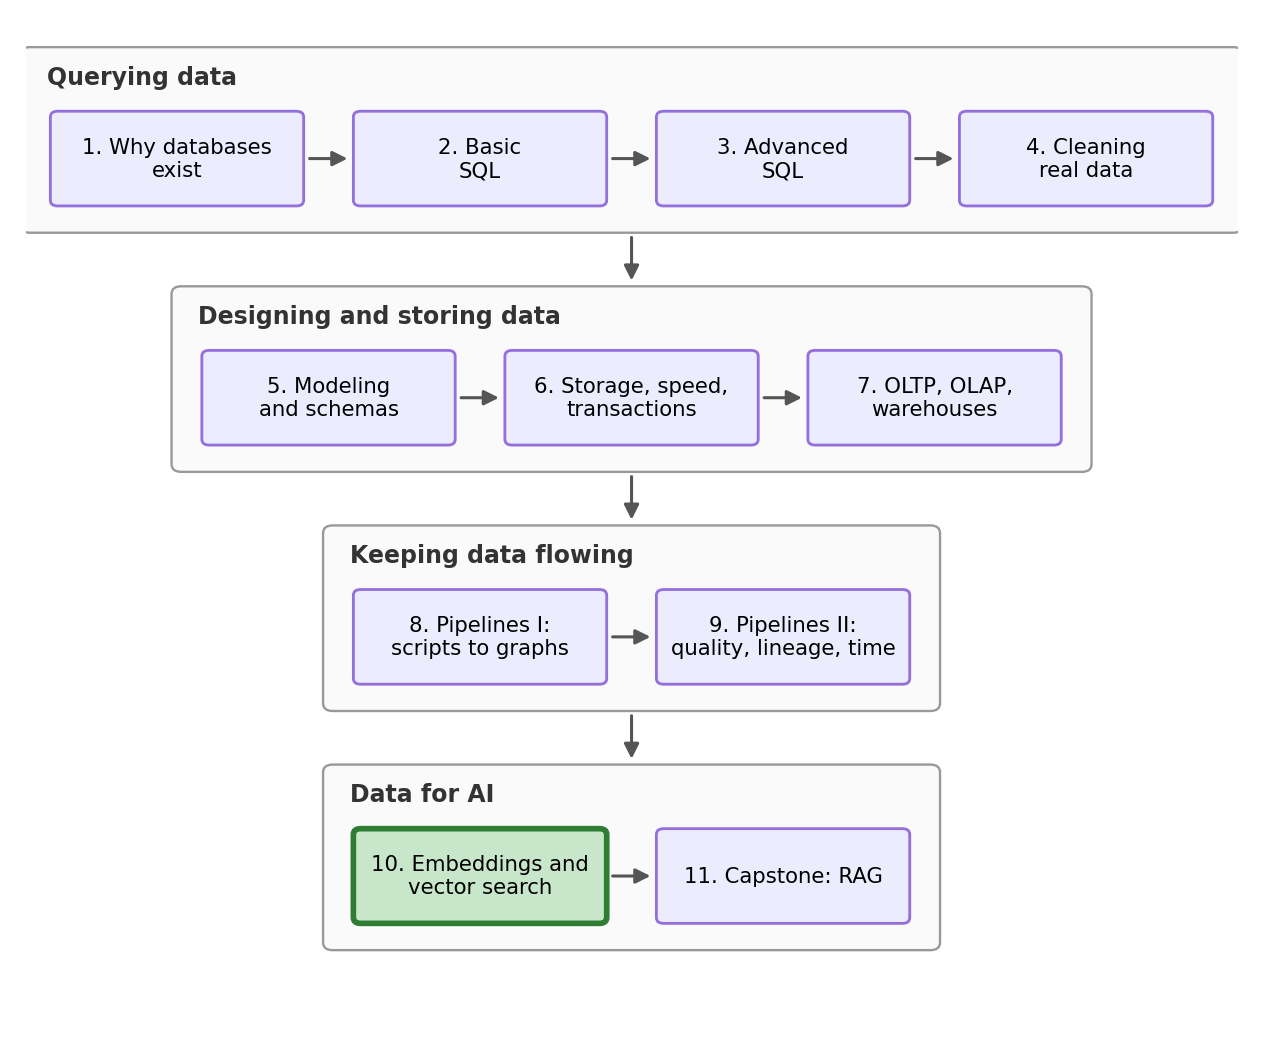

A new arc begins here. Nine notebooks gave us a warehouse filled with
data we can trust, updated daily by a pipeline that clearly validates
its own work. This notebook is about what happened when different data
appears: real text, from real people.

> **The request, Tuesday 1:55 p.m.** “For the household-debt study we
> pulled 390 published complaint narratives from the CFPB, the American
> consumer-protection agency. We want to know what borrowers actually
> face from debt collectors: find the complaints where people describe
> collectors harassing them. This should take you an hour.”

It will not take an hour. By the end of section 3 you will watch every
tool from Notebooks 2 through 9 fail at this request. First, every
library the notebook needs, and some small config updates:

In [1]:
import os
os.environ["USE_TF"] = "0"                             #transformers: use torch only, skip TensorFlow
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"    #disable a Windows-only cache warning
import sqlite3
import duckdb
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 100)             #show more of each text column, needed for cell output readability

## 2. Text Data

For the first time in this stream nothing is simulated. The [Consumer
Financial Protection
Bureau](https://www.consumerfinance.gov/data-research/consumer-complaints/)
publishes complaints that American consumers file against financial
companies. The CFPB also publishes their story in their own words,
scrubbed of any personal information; every `XXXX` you see is that
anonymization, blocking names, dates, and amounts. The database is in
the public domain.

We pulled 390 of these stories from March 2023, drawn evenly from six
complaint categories. Our target category is labelled **Communication
tactics**: the debt-collection label that covers harassing calls.
Consumers pick these labels themselves from a fixed menu when they file,
which gives us a free answer key for this notebook. We will check how
many of our results from different approaches land in the
**Communication tactics** category.

In [2]:
complaints = pd.read_csv("datasets/cfpb_complaints.csv")

print("narratives:", len(complaints))
complaints["issue"].value_counts()

narratives: 390

issue
Trouble during payment process                     65
Dealing with your lender or servicer               65
Problem with a purchase shown on your statement    65
Incorrect information on your report               65
Communication tactics                              65
Managing an account                                65
Name: count, dtype: int64

390 total narratives, 65 in each of six categories, including the 65
under Communication tactics. Here is what three of them look like - we
print the first 250 characters of each:

In [3]:
for i in range(3):
    row = complaints.iloc[i]
    print(f"[{row['state']} | {row['issue']}]")
    print(row["narrative"][:250] + "...\n")

[SC | Trouble during payment process]
I made a {$5000.00} payment to the money source company. Before they transferred the mortgage to Mr Cooper. Now Mr Cooper will not acknowledge the {$5000.00} payment on their side. I have proof of payment from XXXX. Please help....

[TX | Dealing with your lender or servicer]
It is my belief, The Department of Education, MOHELA, XXXX, XXXX and XXXX d/b/a the UNITED STATES XXXX are all voluntarily , knowingly and intentionally, individually, and personally undeniable aware of criminal acts of mis-administration and malfeas...

[CO | Trouble during payment process]
We lost our home in a wildfire. This was a federally declared disaster. Cardinal Financial holds our Mortgage Loan. All insurance proceeds checks are made out to Cardinal Financial, as well as us. We have endorsed all checks and forwarded them to Car...


Each entry has the state that it comes from along with a deeper category
label like “Trouble during payment process.” This is real text about
experiences real Americans had; let’s dig deeper and search for
harassment.

## 3. Keyword search is limited

Notebook 4 gave us a tool we can use here. The SQL command `LIKE`, where
`%` matches any run of characters, so `'%call%'` matches “call” anywhere
inside a narrative. In these stories harassment usually happens over the
phone, so `call` is an obvious keyword for us to try. Another option is
harass, but people often describe situations of harassment without
explicitly using the word. We load the complaints into a scratch SQLite
database and try it:

In [4]:
lite = sqlite3.connect(":memory:")
complaints.to_sql("complaint", lite, index=False)

print(pd.read_sql("SELECT COUNT(*) FROM complaint WHERE narrative LIKE '%call%'", lite).iloc[0, 0],
      "of 390 complaints mention 'call'")
pd.read_sql("""SELECT issue, COUNT(*) AS mentions_call FROM complaint
               WHERE narrative LIKE '%call%' GROUP BY issue ORDER BY issue""", lite)

163 of 390 complaints mention 'call'

163 of 390, spread across all six categories. As a filter the word is
worthless. Let’s look deeper at some of the 163 hits.

In [5]:
they_call = pd.read_sql("""SELECT narrative FROM complaint
    WHERE issue = 'Communication tactics' AND narrative LIKE '%calls me%'
    ORDER BY complaint_id LIMIT 1""", lite)
print("them calling:")
print(they_call.iloc[0]["narrative"][:250] + "...\n")

i_called = pd.read_sql("""SELECT narrative FROM complaint
    WHERE narrative LIKE '%I called%' AND issue != 'Communication tactics'
    ORDER BY complaint_id""", lite)
print("calling them:")
print(i_called.iloc[1]["narrative"][:250] + "...")

them calling:
Commenity Bank calls me numerous times a day under different numbers, as well as blocked numbers that show up as unknown and no caller ID. I explained my situation to them a few months ago, that I am unable to make a payment currently, but they conti...

calling them:
On XX/XX/2022, I wrote to Comenity Bank/Victoria Secret to dispute 2 late payments showing on my account. I advised them that I called member service when I got out of the hospital to file a claim with Account Assure as I would be unable to make my p...

The keyword “call” is correctly mentioned in both, but the situations
are polar opposites. In the first, the calls *are* the harassment:
numerous times a day, from different numbers, from blocked numbers. In
the second, the customer is the one calling, while trying to fix a
billing dispute. `LIKE` sees the text string “call” and nothing more:
not who is calling, not how often, not why. Meaning lives in context,
and raw letters don’t carry contextual meaning.

The next logical idea we can try is dropping the generic word (call) and
combining precise phrasings instead:

> **Predict first.** Four patterns: `calls me`, `stop calling`,
> `keep calling`, `threaten`. There are 65 Communication tactics
> complaints. How many will the new chain catch, and will everything it
> catches be one of them?

In [6]:
chain = pd.read_sql("""SELECT issue FROM complaint
                       WHERE narrative LIKE '%calls me%' OR narrative LIKE '%stop calling%'
                          OR narrative LIKE '%keep calling%' OR narrative LIKE '%threaten%'""", lite)
print(f"the chain catches {len(chain)} complaints")
chain["issue"].value_counts()

the chain catches 26 complaints

issue
Communication tactics                              20
Trouble during payment process                      3
Dealing with your lender or servicer                2
Problem with a purchase shown on your statement     1
Name: count, dtype: int64

26 hits: 20 from our target category, and 6 from other categories. We
improved our precision quite significantly, but two problems remain.
First the strays; here is one, caught by `threaten` alone:

In [7]:
stray = pd.read_sql("""SELECT issue, narrative FROM complaint
                       WHERE narrative LIKE '%threaten%' AND issue != 'Communication tactics'
                       ORDER BY complaint_id LIMIT 1""", lite)
print(f"[{stray.iloc[0]['issue']}]")
print(stray.iloc[0]["narrative"][:250] + "...")

[Trouble during payment process]
Plaza Home Mortgage has threatened on two occasions, to charge me approximately {$380.00} for supposedly not having homeowners ' insurance from XX/XX/XXXX to XX/XX/XXXX. I've called this company a total of four times in an attempt to correct the issu...

A mortgage company “threatened” a 380 dollar insurance charge. This is
not the debt collector harassment we are looking for; there are no debt
collectors or repeated calls. The bigger problem is everything the chain
never sees:

In [8]:
missed = pd.read_sql("""SELECT narrative FROM complaint
    WHERE issue = 'Communication tactics'
      AND narrative NOT LIKE '%calls me%' AND narrative NOT LIKE '%stop calling%'
      AND narrative NOT LIKE '%keep calling%' AND narrative NOT LIKE '%threaten%'
    ORDER BY complaint_id""", lite)
print(f"{len(missed)} harassment complaints match none of the four patterns\n")
for i in range(3):
    print(missed.iloc[i]["narrative"][:250] + "...\n")

45 harassment complaints match none of the four patterns

XX/XX/23 - Received a phone call from XXXX asking to speak with XXXX XXXX. Informed person that they have the wrong number and that I've received multiple phone calls in the pass from this number asking to speak with the same person. I've explained I...

I've been contacted by this XXXX company about 20 times by completely different ( spoofed ) phone numbers. Each time I tell them I am not the person that they are looking for and to take me off their calling list. I recently got a string of SMS messa...

National Credit Systems , INC is operating with out a state license and not registration in South Carolina according to the XXXX consumer access report. They have added two collections on XXXX and XXXX and I would like them removed for this illegal t...


45 of the 65 harassment complaints slip through all four patterns. Read
how people actually write: “I’ve received multiple phone calls in the
pass from this number asking to speak with the same person”, “contacted
by this XXXX company about 20 times by completely different ( spoofed )
phone numbers”. These are examples of the harassment we are looking for,
but they are not written in the same way; we are running into
**synonym** and **phrasing** failures. Every pattern we add fixes some
previous misses, but at the same time creates new ones, and we could
keep adding `OR` lines for a week without converging to all 65. This is
simply a bad approach.

There is one more over-arching issue here: a complaint saying “the
collector never calls me” would still match `calls me`, because matching
characters cannot see a “never”. That is a **negation** failure. `LIKE`
matches characters. Our task asked for a meaning. Let’s look at a
popular way to derive that meaning.

## 4. Embeddings: coordinates of meaning

> **Embeddings**
>
> An **embedding** is a list of numbers that records where a piece of
> text sits in a space of meanings. A model trained on billions of
> sentences has learned which words tend to appear together, and it uses
> that experience to place every text at a point: texts about the same
> topic land close together, unrelated texts land far apart. When
> similar text lands together we can compute distance and similarity
> mathematically.

This all sounds quite abstract, and if you have not studied other
natural language processing (NLP) techniques or linear algebra it may be
unfamiliar. We will start with an example in two dimensions and build up
from there.

A list of two numbers, like $(3, 4)$, is a **vector**: an arrow from the
origin to that point in the plane. In the case of embeddings two arrows
pointing the same direction mean they are similar, while two arrows at a
right angle are completely unrelated. The standard measurement of “how
much do two arrows agree” is **cosine similarity**, the cosine of the
angle between them. Mathematically it is:

$$
\text{similarity}(a, b) \;=\; \cos(\theta) \;=\; \frac{a \cdot b}{\lVert a \rVert \, \lVert b \rVert}
$$

At the top, the **dot product** $a \cdot b$ multiplies coordinates from
the same axis and then sums them. The **length** $\lVert a \rVert$ is
just how long the arrow is. The result is $1$ when the arrows point the
same way, $0$ at a right angle, and $-1$ when they point in opposite
directions. So cosine similarity ranges from $1$ to $-1$, with $1$ being
identical and $-1$ being opposite.

Let’s show this visually. The next cell builds three vectors: `b` points
in a direction similar to `a`, and `c` sits at a right angle to it. The
`cosine` function is the formula above in Python. We draw both
comparisons side by side, with the computed similarity in each title:

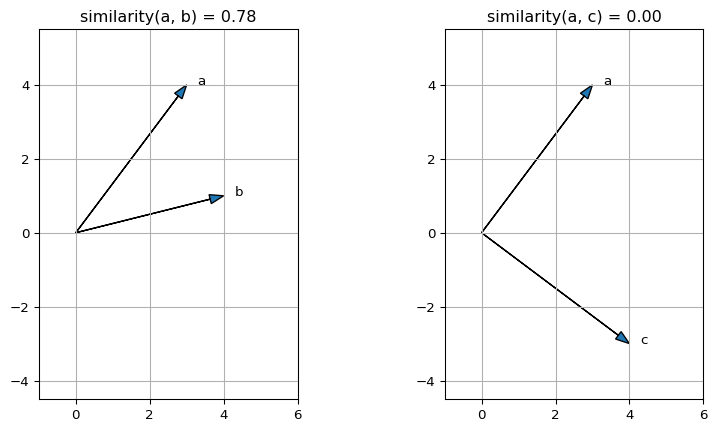

In [9]:
a = np.array([3, 4])
b = np.array([4, 1])      #points in a similar direction to a
c = np.array([4, -3])     #at a right angle to a

def cosine(u, v):
    return u @ v / (np.linalg.norm(u) * np.linalg.norm(v))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, other, name in [(axes[0], b, "b"), (axes[1], c, "c")]:
    ax.arrow(0, 0, a[0], a[1], head_width=0.25, length_includes_head=True)
    ax.arrow(0, 0, other[0], other[1], head_width=0.25, length_includes_head=True)
    ax.text(a[0] + 0.3, a[1], "a")
    ax.text(other[0] + 0.3, other[1], name)
    ax.set_xlim(-1, 6)
    ax.set_ylim(-4.5, 5.5)
    ax.grid(True)
    ax.set_aspect("equal")
    ax.set_title(f"similarity(a, {name}) = {cosine(a, other):.2f}")
plt.show()

The vectors `a` and `b` are similar so they score a positive and high
similarity ($0.78$); the right angle from `a` and `c` scores exactly 0.
The lengths of the arrows never matter, only the angle between them.

Everything we just did in 2 dimensions works in any number of
dimensions, 2, 200 or 2000. The model we use is `all-MiniLM-L6-v2`, a
small, free, commonly used sentence-embedding model that maps any text
to 384 dimensions. The initial download is about 90 MB; after that it
loads from a local cache. If you want to go deeper into the NLP side of
all this we have a [prAxIs text embeddings
workshop](https://ubcecon.github.io/praxis-ubc/docs/hist_workshop/text_embeddings_workshop.html).

Let’s load the model.

In [10]:
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
model = AutoModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2").eval()

The model hands back one vector *per token*, and we want one per *text*.
A **token** is the small unit of text the model actually reads, produced
by the model’s own tokenizer. Let’s look at how the tokenizer works on
two example phrases: **“The collector keeps calling about my debt”** and
**“I called Comenity about my paycheque”**.

In [11]:
print(tokenizer.tokenize("The collector keeps calling about my debt"))
print(tokenizer.tokenize("I called Comenity about my paycheque"))

['the', 'collector', 'keeps', 'calling', 'about', 'my', 'debt']
['i', 'called', 'come', '##nity', 'about', 'my', 'pay', '##che', '##que']

The first sentence is seven everyday words, so it becomes seven tokens.
These words already exist in the model’s training set so it just re-uses
the ones it knows. In the second, the model has never seen the firm
“Comenity” or the Canadian spelling of “paycheque”, so it builds them
from pieces: “come” plus “##nity”, “pay” plus “##che” plus “##que”,
where `##` marks a fragment that continues the previous piece. Every
token gets its own 384-number vector, which is why a sentence output is
a bunch of values which together form its vector in 384-dimension space.

To get our embeddings we run four steps: tokenize the batch, run the
model, average each text’s token vectors into one, then scale every
vector to length one. We also explicitly never train this model, we just
use it as is.

In [12]:
def embed(texts):
    encoded = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
    with torch.no_grad():
        output = model(**encoded)                                #one vector per token
    mask = encoded["attention_mask"].unsqueeze(-1)               #1 for real tokens, 0 for padding
    vectors = (output.last_hidden_state * mask).sum(1) / mask.sum(1)   #mean pooling
    vectors = vectors / vectors.norm(dim=1, keepdim=True)        #stretch to length one
    return vectors.numpy()

demo = embed(["The collector calls me five times a day", "They will not stop phoning me at all hours"]) #the sentences we compare in this demo cell
print("shape:", demo.shape)
print("first five numbers of the first vector:", np.round(demo[0, :5], 3))   #np.round trims the printout
print(f"similarity = {demo[0] @ demo[1]:.3f}")

shape: (2, 384)
first five numbers of the first vector: [-0.04   0.081  0.001  0.011 -0.093]
similarity = 0.341

The first five values of our 384 dimension vector are
$-0.04, 0.081, 0.001, 0.011, -0.093$, and individually they mean
nothing; only the whole direction of all 384 numbers does.

We can look at how different sentences compare, we will use **“The
collector calls me five times a day”** as our baseline and contrast it
to 4 other sentences and compute each one’s cosine similarity. You can
read the other sentences in the cell code below.

In [13]:
#Comparison sentences below
pairs = [("The collector calls me five times a day", "They will not stop phoning me at all hours"),
         ("The collector calls me five times a day", "My credit report shows an account that is not mine"),
         ("The collector calls me five times a day", "My escrow analysis came back wrong this year"),
         ("The collector calls me five times a day", "The collector never calls me at all")]
rows = []
for a, b in pairs:
    va, vb = embed([a, b])
    rows.append({"sentence_b": b, "similarity": round(float(va @ vb), 3)})
pd.DataFrame(rows)

The phone-call paraphrase is close ($0.341$), the credit-report
complaint is more unrelated at $0.191$, the escrow complaint furthest
($0.144$). What really matters for us is the ordering. Now look at the
last row: this is the sentence with the exact opposite meaning and it
scores a $0.754$, the highest on the table.

If you expected a negative number, which represents arrows pointing
exactly opposite ways, then you would be mistaken, as a negation is not
an anti-topic. Embeddings measure *topic*, never truth or stance. Both
sentences are precisely about a collector and calling, so their arrows
are very similar. The model correctly identifies these as similar.

Now the whole text corpus. The narratives are long, so we embed them in
batches of 64 and collect the results into one list. The warehouse then
stores the vectors in a column next to the text. DuckDB has a column
type for exactly this, a fixed-length array written `FLOAT[384]`, and
Notebook 9’s `DESCRIBE` confirms what we built:

In [14]:
texts = complaints["narrative"].tolist()               #.tolist turns the column into a plain list
vectors = []
for start in range(0, len(texts), 64):                 #count upwards in steps of 64
    vectors.extend(embed(texts[start:start + 64]))     #.extend appends the whole batch at once
complaints["embedding"] = [v.tolist() for v in vectors]

warehouse = duckdb.connect("datasets/wage_warehouse.duckdb")
warehouse.execute("""CREATE OR REPLACE TABLE complaint AS
    SELECT complaint_id, state, issue, narrative, CAST(embedding AS FLOAT[384]) AS embedding
    FROM complaints""")

warehouse.execute("DESCRIBE complaint").df()[["column_name", "column_type"]]

The complaint table now holds text and coordinates in different columns.
Before searching, let’s look at the space itself. 384 dimensions are
impossible to visualize (and would be pretty meaningless anyway), so PCA
(principal component analysis) pushes them down to the two directions
with the most spread; distances survive the pressing only roughly, but
clusters stay clearly visible:

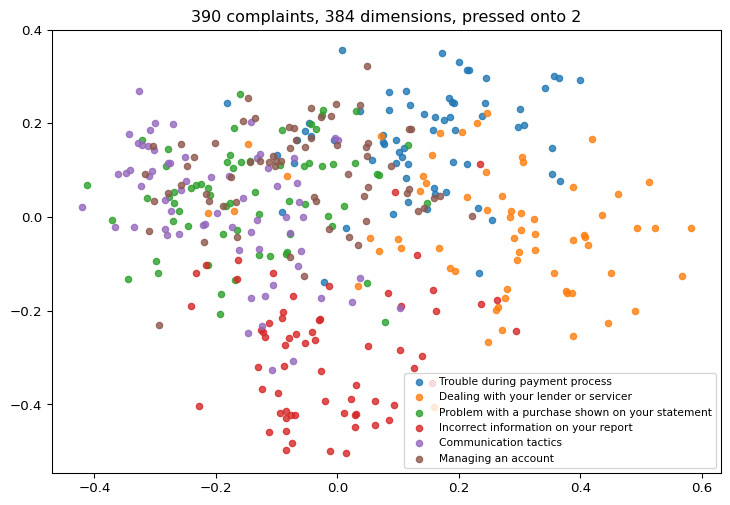

In [15]:
flat = PCA(n_components=2, random_state=42).fit_transform(np.array(vectors))   #learn and apply the 2-D projection

plt.figure(figsize=(9, 6))
for issue in complaints["issue"].unique():
    inside = (complaints["issue"] == issue).to_numpy()                         #True/False mask for this category
    plt.scatter(flat[inside, 0], flat[inside, 1], label=issue, s=22, alpha=0.8)
plt.legend(fontsize=8)
plt.title("390 complaints, 384 dimensions, pressed onto 2")
plt.show()

We can see some rough structure, even though it is messy. Mortgage and
payment troubles drift to the upper right, student-loan complaints sit
closer to the right edge, and the credit-report disputes cluster towards
the bottom. The model never saw the CFPB’s labels, and still drew this
structure on its own.

## 5. Vector search with ORDER BY

To search this space we don’t need any new tools. DuckDB’s
`array_cosine_distance` computes one minus the cosine similarity from
section 4, so 0 means identical direction and bigger means further
apart. We wrap it in a helper function that shows the first 80
characters of each hit, and start with the literal word from the request
“harassment”:

In [16]:
def search(query, k=5):
    qv = embed([query])[0].tolist()
    return warehouse.execute("""SELECT round(array_cosine_distance(embedding, CAST(? AS FLOAT[384])), 3) AS distance,
                                       issue, substr(narrative, 1, 80) AS start_of_narrative
                                FROM complaint ORDER BY distance LIMIT ?""", [qv, k]).df()

search("harassment")

Four of the five issues in our output are from the Communication tactics
label, this is already better, but let’s inspect the top result:

In [17]:
top_hit = warehouse.execute("""SELECT narrative FROM complaint
    ORDER BY array_cosine_distance(embedding, CAST(? AS FLOAT[384])) LIMIT 1""",
    [embed(["harassment"])[0].tolist()]).df()
print(top_hit.iloc[0]["narrative"][:400] + "...")

XXXX, XXXX XXXX XXXX with Navient has contacted my employer and has attempted to harass me and my employer. He wants my employer to call him and to send him personal information on me. In an attempt to get them to put pressure on me or possibly fire me. This tactic is unprofessional and unethical. Please stop Navient from using these bullying techniques on Alabama employers and employees. 

Thank ...

It is a *student-loan* complaint, filed under “Dealing with your lender
or servicer”, about Navient contacting the writer’s employer. The
consumer filed it under servicing; the model read the content, and saw
it as a harassment story. The label and the model disagree, but in my
opinion the model might be right; this could be classified as
harassment. Regardless of your stance on this, a one-word query is a
vague point in meaning space. Let’s do something else and phrase the
query as “debt collectors harassing me with constant phone calls” which
is far more detailed and carries greater meaning for the model than just
“harassment”.

In [18]:
search("debt collectors harassing me with constant phone calls", 10)

Ten out of ten from the target category, at distances 0.247 to 0.360.
Read what the ranking found: “keeps calling me multiple times a day
every single day”, “CALLS EVERY SINGLE DAY 2-3X/DAY, AT ALL HOURS”,
“calls me numerous times a day under different numbers”. None of those
rows contain the word “harass”. No keyword chain built this list, and
none ever could. Meaning did, easily.

## 6. The scoreboard, and where keywords still win

The CFPB’s labels let us grade both search methods. The keyword chain
caught 26 complaints, 20 of them actually in the target category. For
vector search, count the labels deeper into the ranking:

In [19]:
qv = embed(["debt collectors harassing me with constant phone calls"])[0].tolist()

top20 = warehouse.execute("""SELECT issue, substr(narrative, 1, 80) AS start_of_narrative FROM complaint
    ORDER BY array_cosine_distance(embedding, CAST(? AS FLOAT[384])) LIMIT 20""", [qv]).df()
print(f"top 20 by distance: {(top20['issue'] == 'Communication tactics').sum()} carry the target label")
top20

top 20 by distance: 18 carry the target label

18 of the top 20, from a single query written in plain language. We can
read twenty complaints instead of the whole 390, and that is the whole
point of retrieval. Imagine if instead of 390 we used the millions that
the CFPB holds; we would never be able to read all of it.

This is already an excellent result, but vector search is not always the
perfect tool for everything. Watch what happens when the query is an
exact token instead of a meaning. Some complaints cite chapter and verse
of debt-collection law, we will search for the FDCPA, statute 15 U.S.C.
1692, which is a law that protects consumers from abusive, deceptive,
and unfair debt collection practices by third-party collection agencies.

This time we skip our `search` helper and write the query directly, with
a `CASE` column (Notebook 2’s if-else statement) that labels which law
each hit actually cites.

In [20]:
qv_law = embed(["section 1692 FDCPA violation"])[0].tolist()

warehouse.execute("""SELECT round(array_cosine_distance(embedding, CAST(? AS FLOAT[384])), 3) AS distance,
                            CASE WHEN narrative LIKE '%1692%' THEN 'cites 1692, the FDCPA'
                                 WHEN narrative LIKE '%1681%' THEN 'cites 1681, the FCRA'
                                 ELSE 'cites no statute' END AS law_cited,
                            substr(narrative, 1, 60) AS start_of_narrative
                     FROM complaint ORDER BY distance LIMIT 5""", [qv_law]).df()

Read the `law_cited` column top to bottom: three statements cite statute
1681, the Fair Credit Reporting Act, a *different* law, two cite no
statute at all, and the complaints that actually cite 1692 appear
nowhere in the top five. To a meaning model, legal boilerplate all looks
alike, and digits carry almost no meaning. Now using Notebook 4’s tool.

In [21]:
pd.read_sql("""SELECT issue,
                      substr(narrative, MAX(instr(narrative, '1692') - 40, 1), 110) AS text_around_1692
               FROM complaint WHERE narrative LIKE '%1692%'""", lite)

Exactly two complaints cite statute 1692, chapter and verse, and SQL’s
normal `LIKE` returns just those two flawlessly. When we are looking for
an exact name or value, keyword search is the correct tool. Real systems
utilize a best of both worlds and run a **filtered vector search**: hard
SQL filters for what must be exact (like our legal statute above),
vector ranking for parts where meaning is valuable. In SQL they combine
naturally. (Vector databases also sell a cousin of this idea under the
name *hybrid search*, which fuses a keyword relevance score with the
vector similarity score instead of filtering first.) Let’s look at
harassment complaints, but only from Texas:

In [22]:
warehouse.execute("""SELECT state, round(array_cosine_distance(embedding, CAST(? AS FLOAT[384])), 3) AS distance,
                            substr(narrative, 1, 80) AS start_of_narrative
                     FROM complaint
                     WHERE state = 'TX'
                     ORDER BY distance LIMIT 3""", [qv]).df()

`WHERE` narrows to Texas exactly, the distance orders by meaning, and
all three are collector-harassment stories. Exactly what we wanted to
find.

## 7. Chunking is a grain decision

One design decision remains before this search is ready: what is one
*row*? Notebook 2 named it the grain of a table. In retrieval the same
question is called **chunking**: when documents are long, what unit do
you embed, the whole document or its pieces? The grain determines what
your retrieval system can find.

Our 390 narratives were short enough to embed whole. But the CFPB also
receives long, multi-page complaints, and we downloaded three real ones
alongside the sample. Each is several paragraphs long. We will search
for one specific detail in one of the stories: the fraud cost the author
refinancing, and student loans for their daughter’s education. We print
the three complaints below along with id, and state. Our target is
**6627407** which is the complaint for California.

In [23]:
longs = pd.read_csv("datasets/cfpb_long_complaints.csv")
longs["narrative"] = longs["narrative"].str.replace("\r", "") 
print(longs[["complaint_id", "issue", "state"]])
print("lengths:", longs["narrative"].str.len().tolist())

   complaint_id                               issue state
0       6627407   Attempts to collect debt not owed    CA
1       6632901  False statements or representation    NY
2       6636826   Attempts to collect debt not owed    TX
lengths: [2220, 3162, 2510]

We are back in plain numpy here, away from DuckDB’s distance column, so
we score with cosine similarity itself: `v @ question`, bigger means
closer, exactly like section 4. `ascending=False` sorts the table
best-first.

> **Predict first.** We embed each complaint as one full text-block and
> search for the education-loans detail. How well do we do?

In [24]:
doc_vectors = embed([t.replace("\n", " ") for t in longs["narrative"]])
question = embed(["the fraud made me unable to get student loans for my daughter"])[0]

longs["similarity"] = [round(float(v @ question), 3) for v in doc_vectors]
longs[["complaint_id", "issue", "similarity"]].sort_values("similarity", ascending=False)

The right complaint does score highest, at 0.452 against 0.390 and
0.364, but a margin of 0.06 is too small to blindly trust. The reason is
**dilution**: one sentence about a daughter’s student loans was averaged
together with multiple-pages of context, disputes, and lawyers. All
three documents ended up making the same over-arching general point,
“long identity-theft complaint”, so picking out a small detail becomes
hard for our model at this grain. Now let’s split every complaint into
paragraphs and embed those instead.

In [25]:
paragraphs = []
for cid, text in zip(longs["complaint_id"], longs["narrative"]):
    for number, para in enumerate(text.split("\n\n"), 1):
        if para.strip():
            paragraphs.append({"complaint_id": cid, "paragraph": number, "text": para.strip()})
para_df = pd.DataFrame(paragraphs)

para_vectors = embed(para_df["text"].tolist())
para_df["similarity"] = [round(float(v @ question), 3) for v in para_vectors]

print(para_df.sort_values("similarity", ascending=False).iloc[0]["text"])
para_df.sort_values("similarity", ascending=False).head(3)[["complaint_id", "paragraph", "similarity", "text"]]

In XXXX, I began receiving calls and letters from Persolve LLC demanding payment for this fraudulent debt. Despite providing proof that the debt was not mine, they refused to remove it from my credit report. As a result, I was denied refinancing for my home, student loans for my daughter 's education, and personal credit cards. As a XXXX  of a company, I was also unable to obtain a corporate card or small business loan, despite our company 's earnings of over {>= $1,000,000} per year.

The correct case wins at $0.614$. Second place, at $0.540$, is a
neighbouring paragraph from the same complaint; the best paragraph from
any *other* complaint is down at 0.401. The margin grew from $0.06$ at
document grain to $0.21$ at paragraph grain, a more trustworthy gap. If
we chunk too big then signals dilute; chunk too small (for example
single words) and there is no meaning left to embed at all. Choosing
that grain is a core design decision of every retrieval system you will
ever build.

## 8. Conclusion

The request said this should take an hour. It took the whole notebook,
but we finished! The single keyword matched 163 of 390 complaints and
told us almost nothing. The four-pattern chain caught 20 of the 65
harassment stories and dragged in 6 unrelated entries. The embedding
search got 18 of its top 20 right from one plain sentence, and even
surfaced harassment stories that were filed under other labels. But it’s
not perfect: it cannot read “never”, and it can’t find statute numbers
that `LIKE` finds perfectly. So instead of choosing one we combine them:
`LIKE` for details and embeddings for meaning.

The big idea to take away is that **meaning itself can now live in a
database.** Once text becomes coordinates in space, searching by meaning
is just `ORDER BY distance LIMIT 5`, and it works alongside every SQL
tool from this stream. Still, nothing we built actually *reads* these
complaints; ranking them is not the same as understanding them. Reading
is a job for a language model, and plugging one into everything we have
built, the schema, the pipeline, the validation, and now this search, is
Notebook 11. One notebook left, and it puts the whole stream together!
We will build a Retrieval-Augmented Generation (RAG) system, a framework
that improves LLM accuracy significantly by grounding its responses.

## Appendix: the landscape beyond tables

Storage follows the shape of the data, and because of that, every shape
has grown its own product category:

| Shape of the data       | Category        | Names you will meet                                            |
|------------------------|------------------------|------------------------|
| rows and columns        | relational      | SQLite, DuckDB, PostgreSQL (Notebooks 1 to 9)                  |
| nested documents        | document store  | MongoDB, CouchDB                                               |
| key and value, at speed | key-value store | Redis, Memcached                                               |
| nodes and edges         | graph database  | Neo4j, Neptune (ex: Notebook 8’s DAGs could be stored here)    |
| vectors                 | vector database | Pinecone, Chroma, pgvector, sqlite-vec, DuckDB’s vss extension |

For vectors specifically the boundary is dissolving: PostgreSQL can use
vectors through `pgvector`, SQLite through `sqlite-vec`, DuckDB through
its `vss` extension, so the “vector database” is increasingly just a
column type in the database you already run. That is exactly how we used
it in this notebook: a `FLOAT[384]` column in plain DuckDB.

## Connections

-   **Back to [Notebook 9](notebook_09_pipelines_two.qmd):** the
    pipeline happily loads and validates batches of text like this one,
    checking counts, nulls, and schema. No check we wrote could ever
    judge what the text *means*. We use embeddings to fix that gap.
-   **Forward to [Notebook 11](notebook_11_capstone_rag.qmd):** the
    capstone. A language model finally joins us and reads what this
    notebook’s search retrieves, and everything underneath, schema, ETL,
    validation, lineage, becomes one complete system you build.

### References

-   Consumer Financial Protection Bureau. *Consumer Complaint Database.*
    https://www.consumerfinance.gov/data-research/consumer-complaints/
    The source of every narrative in this notebook: public domain,
    published with consumer consent, scrubbed of identifying details
    ([how the CFPB shares complaint
    data](https://www.consumerfinance.gov/complaint/data-use/)). Our
    390-row sample comes from March 2023 across six issue categories.
-   Reimers, N., & Gurevych, I. (2019). *Sentence-BERT: Sentence
    Embeddings using Siamese BERT-Networks.* EMNLP 2019. The paper
    behind the sentence-transformers family our model comes from.
-   Hugging Face model card. *sentence-transformers/all-MiniLM-L6-v2.*
    https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2 The
    exact model, its training recipe, and the mean-pooling code section
    4 adapts.
-   DuckDB documentation. *Array functions and the vss extension.*
    https://duckdb.org/docs/stable/sql/functions/array and
    https://duckdb.org/docs/stable/core_extensions/vss
    `array_cosine_distance` and friends, plus the HNSW index for when
    corpora outgrow full scans.
-   Garcia, A. *sqlite-vec.* https://github.com/asg017/sqlite-vec Vector
    search inside SQLite, proof that even the smallest database in this
    stream can hold the newest shape.

------------------------------------------------------------------------